# Data Loading

In [15]:
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import seaborn as sns
import pandas as pd


DATA_DIR = 'data'

def get_sit_to_stand_files(data_dir=DATA_DIR):
    """
    Returns: list
        Two lists of file paths, one for yes and one for no
    """

    # Create the pattern to match files like {name}_1_{yes/no}.csv
    pattern = os.path.join(data_dir, '*_1_*.csv')
    
    # Get all matching files
    files = glob.glob(pattern)
    
    # Filter to ensure we only get yes/no files
    files = [f for f in files if f.endswith('_yes.csv') or f.endswith('_no.csv')]

    # Sort the files to ensure consistent ordering
    files.sort()

    # Return two lists of files, one for yes and one for no
    return [f for f in files if f.endswith('_yes.csv')], [f for f in files if f.endswith('_no.csv')]

def get_water_task_files(data_dir=DATA_DIR):
    """
    Returns: list
        Two lists of file paths, one for yes and one for no
    """

    # Create the pattern to match files like {name}_1_{yes/no}.csv
    pattern = os.path.join(data_dir, '*_2_*.csv')

    # Get all matching files
    files = glob.glob(pattern)
    
    # Filter to ensure we only get yes/no files
    files = [f for f in files if f.endswith('_yes.csv') or f.endswith('_no.csv')]

    # Sort the files to ensure consistent ordering
    files.sort()

    # Return two lists of files, one for yes and one for no
    return [f for f in files if f.endswith('_yes.csv')], [f for f in files if f.endswith('_no.csv')]

def get_step_count_task_files(data_dir=DATA_DIR):
    """
    Returns: list
        Two lists of file paths, one for yes and one for no
    """

    # Create the pattern to match files like {name}_1_{yes/no}.csv
    pattern = os.path.join(data_dir, '*_3_*.csv')

    # Get all matching files
    files = glob.glob(pattern)
    
    # Filter to ensure we only get yes/no files
    files = [f for f in files if f.endswith('_yes.csv') or f.endswith('_no.csv')]

    # Sort the files to ensure consistent ordering
    files.sort()

    # Return two lists of files, one for yes and one for no
    return [f for f in files if f.endswith('_yes.csv')], [f for f in files if f.endswith('_no.csv')]
    
# Construct dataframes for each task

import pandas as pd

step_count_task_yes, step_count_task_no = get_step_count_task_files()

dfs_step_count_task_yes = [pd.read_csv(f) for f in step_count_task_yes]
dfs_step_count_task_no = [pd.read_csv(f) for f in step_count_task_no]

def preprocess_sit_to_stand_data(df):
    """
    Preprocess the sit to stand data.
    """
    from scipy import signal, integrate
    import numpy as np

    # Convert timestamp_ms to seconds starting from 0
    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].min()) / 1000

    # Calculate magnitude of acceleration 
    df['acceleration_magnitude'] = np.sqrt(
        df['freeAcceleration_m/s²_x']**2 + 
        df['freeAcceleration_m/s²_y']**2 + 
        df['freeAcceleration_m/s²_z']**2
    )

    # Apply detrending to each axis
    df['acc_detrended_x'] = signal.detrend(df['freeAcceleration_m/s²_x'], type='linear')
    df['acc_detrended_y'] = signal.detrend(df['freeAcceleration_m/s²_y'], type='linear')
    df['acc_detrended_z'] = signal.detrend(df['freeAcceleration_m/s²_z'], type='linear')

    # Calculate detrended magnitude of acceleration
    df['acceleration_magnitude_detrended'] = np.sqrt(df['acc_detrended_x']**2 + df['acc_detrended_y']**2 + df['acc_detrended_z']**2)

    # Calculate velocity with detrending
    df['velocity_z'] = integrate.cumulative_trapezoid(df['acc_detrended_z'], df['time_s'], initial=0)
    df['velocity_x'] = integrate.cumulative_trapezoid(df['acc_detrended_x'], df['time_s'], initial=0)
    df['velocity_y'] = integrate.cumulative_trapezoid(df['acc_detrended_y'], df['time_s'], initial=0)

    # Calculate magnitude of velocity
    df['velocity_magnitude'] = np.sqrt(df['velocity_x']**2 + df['velocity_y']**2 + df['velocity_z']**2)

    # Calculate position with detrending
    df['position_z'] = integrate.cumulative_trapezoid(df['velocity_z'], df['time_s'], initial=0)
    df['position_x'] = integrate.cumulative_trapezoid(df['velocity_x'], df['time_s'], initial=0)
    df['position_y'] = integrate.cumulative_trapezoid(df['velocity_y'], df['time_s'], initial=0)

    # Apply a moving average filter to the acceleration_magnitude
    df['acceleration_magnitude_filtered'] = df['acceleration_magnitude'].rolling(window=20).mean()
    return df


dfs_standard = [preprocess_sit_to_stand_data(df) for df in dfs_step_count_task_yes]
dfs_cognitive = [preprocess_sit_to_stand_data(df) for df in dfs_step_count_task_no]


# Data Preprocessing 

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy import signal, integrate
import numpy as np

def preprocess_walking_data(df):
    """Preprocess walking data for step analysis"""
    df_clean = df.drop_duplicates().reset_index(drop=True)
    
    # Convert timestamp to relative seconds
    df_clean['timestamp_sec'] = (df_clean['timestamp_ms'] - df_clean['timestamp_ms'].iloc[0]) / 1000.0
    
    # Calculate acceleration magnitude
    df_clean['magnitude'] = np.sqrt(
        df_clean['freeAcceleration_m/s²_x']**2 + 
        df_clean['freeAcceleration_m/s²_y']**2 + 
        df_clean['freeAcceleration_m/s²_z']**2
    )

    # Calculate velocity magnitude]
    df_clean['time_s'] = (df_clean['timestamp_ms'] - df_clean['timestamp_ms'].min()) / 1000
    

    # Apply detrending to each axis
    df_clean['acc_detrended_x'] = signal.detrend(df_clean['freeAcceleration_m/s²_x'], type='linear')
    df_clean['acc_detrended_y'] = signal.detrend(df_clean['freeAcceleration_m/s²_y'], type='linear')
    df_clean['acc_detrended_z'] = signal.detrend(df_clean['freeAcceleration_m/s²_z'], type='linear')

    print('Detrended')

    # Calculate detrended magnitude of acceleration
    df_clean['acceleration_magnitude_detrended'] = np.sqrt(df_clean['acc_detrended_x']**2 + df_clean['acc_detrended_y']**2 + df_clean['acc_detrended_z']**2)

    # Calculate velocity with detrending
    df_clean['velocity_z'] = integrate.cumulative_trapezoid(df_clean['acc_detrended_z'], df_clean['time_s'], initial=0)
    df_clean['velocity_x'] = integrate.cumulative_trapezoid(df_clean['acc_detrended_x'], df_clean['time_s'], initial=0)
    df_clean['velocity_y'] = integrate.cumulative_trapezoid(df_clean['acc_detrended_y'], df_clean['time_s'], initial=0)

    # Calculate magnitude of velocity
    df_clean['velocity_magnitude'] = np.sqrt(df_clean['velocity_x']**2 + df_clean['velocity_y']**2 + df_clean['velocity_z']**2)
    
    return df_clean

def detect_steps_and_variability(magnitude, fs=60, plot=True):
    if len(magnitude) < fs:
        return 0, 0, [], []
    
    cb_colors = sns.color_palette("colorblind", n_colors=3)
    
    signal_std = np.std(magnitude)
    signal_mean = np.mean(magnitude)
    threshold = signal_mean + 0.5 * signal_std
    
    # Find steps (peaks) - using raw magnitude
    min_distance = int(fs * 0.4)  # 400ms minimum between steps
    peaks, _ = find_peaks(
        magnitude,
        height=threshold,
        distance=min_distance,
        prominence=signal_std * 0.3
    )
    
    # Calculate step intervals and variability
    if len(peaks) > 1:
        step_intervals = np.diff(peaks) / fs  # Convert to seconds
        step_interval_mean = np.mean(step_intervals)
        step_interval_std = np.std(step_intervals)
        step_interval_cv = step_interval_std / step_interval_mean if step_interval_mean > 0 else 0
    else:
        step_intervals = []
        step_interval_cv = 0
    
    return len(peaks), step_interval_cv, step_intervals, peaks

def create_single_analysis_window(df, fs=60):
    """
    Create single 30-second analysis window per participant
    Uses the entire recording duration (no sliding windows)
    """
    if df.empty or 'timestamp_sec' not in df.columns:
        return None
    
    # Use entire recording duration
    total_duration = df['timestamp_sec'].iloc[-1] - df['timestamp_sec'].iloc[0]
    
    # Ensure we have at least 20 seconds of data for meaningful analysis
    if total_duration >= 20.0 and len(df) >= fs * 20:
        return df.copy()
    else:
        return None

In [17]:
import seaborn as sns
import os
import pandas as pd

sns.set_style('whitegrid')
sns.set_palette('colorblind')
# Get all participants
participants = []
if os.path.exists('data'):
    files = os.listdir('data')
    for file in files:
        if '_3_' in file and file.endswith('.csv'):
            participant = file.split('_')[0]
            if participant not in participants:
                participants.append(participant)

participants = sorted(participants, key=lambda x: int(x[1:]) if x.startswith('p') else float('inf'))



In [18]:
# Storage for results
participant_data = []
all_step_intervals = []

print(f"\n🚶 EXTRACTING MULTI-FEATURE STEP TIMING DATA")
print("=" * 50)

for participant in participants:
    print(f"\nProcessing participant: {participant}")
    
    no_load_file = f'data/{participant}_3_no.csv'
    with_load_file = f'data/{participant}_3_yes.csv'
    
    participant_results = {
        'participant': participant,
        'no_load_cv': None,
        'with_load_cv': None,
        'no_load_step_count': 0,
        'with_load_step_count': 0,
        'no_load_intervals': [],
        'with_load_intervals': [],
        'no_load_mean_acceleration_magnitude': None,
        'with_load_mean_acceleration_magnitude': None,
        'no_load_mean_velocity_magnitude': None,
        'with_load_mean_velocity_magnitude': None
    }
    
    for condition, file_path, label in [('No Load', no_load_file, 0), 
                                       ('With Load', with_load_file, 1)]:
        try:
            if os.path.exists(file_path):
                # Load and preprocess
                df = pd.read_csv(file_path)
                df_processed = preprocess_walking_data(df)
                participant_results['no_load_mean_acceleration_magnitude'] = df_processed['magnitude'].mean()
                participant_results['with_load_mean_acceleration_magnitude'] = df_processed['magnitude'].mean()
                participant_results['no_load_mean_velocity_magnitude'] = df_processed['velocity_magnitude'].mean()
                participant_results['with_load_mean_velocity_magnitude'] = df_processed['velocity_magnitude'].mean()
                
                # Create single analysis window (entire recording)
                window = create_single_analysis_window(df_processed, fs=60)
                
                print(f"  {condition:12}: {len(df_processed)} samples, {df_processed['timestamp_sec'].iloc[-1]:5.1f}s")
                
                if window is not None:
                    # Extract step timing variability from entire recording
                    step_count, step_cv, intervals, peaks = detect_steps_and_variability(
                        window['magnitude'].values, fs=60
                    )
                    
                    if step_count > 5:  # Need at least 5 steps for meaningful CV
                        if label == 0:  # No load
                            participant_results['no_load_cv'] = step_cv
                            participant_results['no_load_step_count'] = step_count
                            participant_results['no_load_intervals'] = intervals
                        else:  # With load
                            participant_results['with_load_cv'] = step_cv
                            participant_results['with_load_step_count'] = step_count
                            participant_results['with_load_intervals'] = intervals
                        
                        all_step_intervals.extend(intervals)
                
        except Exception as e:
            print(f"  {condition:12}: Error processing: {str(e)}")
    
    # Only add participants with data from both conditions
    if (participant_results['no_load_cv'] is not None and 
        participant_results['with_load_cv'] is not None):
        participant_data.append(participant_results)


# Create the model dataframe with multi-features
model_data = []
for p_data in participant_data:
    participant = p_data['participant']
    
    # No Load condition
    model_data.append({
        'participant': participant,
        'cognitive_load': 0,
        'step_interval_cv': p_data['no_load_cv'],
        'step_count': p_data['no_load_step_count'],
        'step_rate': p_data['no_load_step_count'] / 30.0,  # steps per second
        'step_efficiency': 1 / p_data['no_load_cv'] if p_data['no_load_cv'] > 0 else 0,
        'activity_regularity': p_data['no_load_step_count'] * (1 / p_data['no_load_cv'] if p_data['no_load_cv'] > 0 else 0),
        'mean_acceleration_magnitude': p_data['no_load_mean_acceleration_magnitude'],
        'mean_velocity_magnitude': p_data['no_load_mean_velocity_magnitude']
    })
    
    # With Load condition
    model_data.append({
        'participant': participant,
        'cognitive_load': 1,
        'step_interval_cv': p_data['with_load_cv'],
        'step_count': p_data['with_load_step_count'],
        'step_rate': p_data['with_load_step_count'] / 30.0,  # steps per second
        'step_efficiency': 1 / p_data['with_load_cv'] if p_data['with_load_cv'] > 0 else 0,
        'activity_regularity': p_data['with_load_step_count'] * (1 / p_data['with_load_cv'] if p_data['with_load_cv'] > 0 else 0),
        'mean_acceleration_magnitude': p_data['with_load_mean_acceleration_magnitude'],
        'mean_velocity_magnitude': p_data['with_load_mean_velocity_magnitude']
    })

model_df = pd.DataFrame(model_data)


🚶 EXTRACTING MULTI-FEATURE STEP TIMING DATA

Processing participant: p4
Detrended
  No Load     : 1786 samples,  29.8s
Detrended
  With Load   : 1787 samples,  29.8s

Processing participant: p5
Detrended
  No Load     : 1779 samples,  29.6s
Detrended
  With Load   : 1789 samples,  29.8s

Processing participant: p8
Detrended
  No Load     : 1800 samples,  30.0s
Detrended
  With Load   : 1790 samples,  29.8s

Processing participant: p9
Detrended
  No Load     : 1790 samples,  29.8s
Detrended
  With Load   : 1785 samples,  29.7s

Processing participant: p10
Detrended
  No Load     : 1798 samples,  30.0s
Detrended
  With Load   : 1792 samples,  29.9s

Processing participant: xhoel
Detrended
  No Load     : 1791 samples,  29.8s
Detrended
  With Load   : 1795 samples,  29.9s

Processing participant: ashish
Detrended
  No Load     : 1793 samples,  29.9s
Detrended
  With Load   : 1791 samples,  29.8s

Processing participant: nour
Detrended
  No Load     : 1794 samples,  29.9s
Detrended
  With

In [19]:
model_df

,participant,cognitive_load,step_interval_cv,step_count,step_rate,step_efficiency,activity_regularity,mean_acceleration_magnitude,mean_velocity_magnitude
0,p4,0,0.388231,40,1.333333,2.575783,103.031337,4.691962,1.283002
1,p4,1,0.545334,37,1.233333,1.833739,67.848334,4.691962,1.283002
2,p5,0,0.430149,36,1.200000,2.324776,83.691952,4.014517,1.075597
3,p5,1,0.548322,31,1.033333,1.823747,56.536147,4.014517,1.075597
4,p8,0,0.327048,45,1.500000,3.057653,137.594401,4.993903,1.023599
5,p8,1,0.476060,38,1.266667,2.100575,79.821855,4.993903,1.023599
6,p9,0,0.452225,39,1.300000,2.211289,86.240264,4.464957,0.988180
7,p9,1,0.430520,38,1.266667,2.322771,88.265300,4.464957,0.988180
8,p10,0,0.346599,46,1.533333,2.885175,132.718061,5.424522,1.079139
9,p10,1,0.598251,38,1.266667,1.671539,63.518470,5.424522,1.079139


# Exploratory Data Analysis

In [20]:
def plot_column_sns(df, column_names=[], title=None):
    sns.set_style('whitegrid')

    color_palatte = 'colorblind'
    sns.set_palette(color_palatte)
    plt.figure(figsize=(18, 6))
    for i, column_name in enumerate(column_names):
        # plot the column_name vs time_s and include appropriate legend
        sns.lineplot(
            data=df,
            x='time_s',
            y=column_name,
            alpha=0.8,
            label=column_name
        ) 
        plt.xticks(np.arange(0.0, 31.5, 1)) 
        plt.yticks(np.arange(-2, 2, 1))
        plt.tight_layout()
    plt.title(title)
    plt.show()

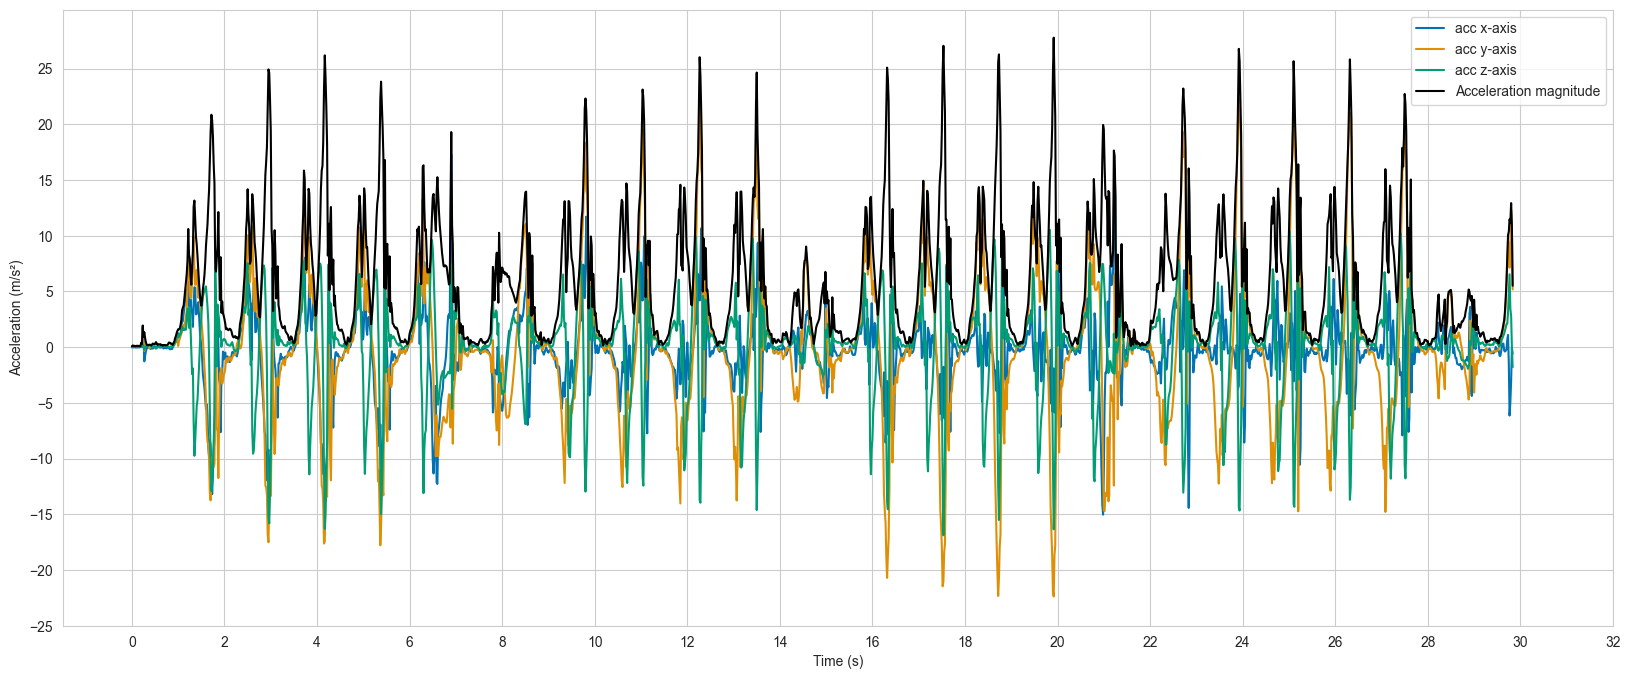

In [21]:
# Plot the acceleration along x, y and z axis for dfs_standard[0]
plt.figure(figsize=(20, 8))
plt.plot(dfs_standard[0]['time_s'], dfs_standard[0]['freeAcceleration_m/s²_x'], label='acc x-axis')
plt.plot(dfs_standard[0]['time_s'], dfs_standard[0]['freeAcceleration_m/s²_y'], label='acc y-axis')
# plt.plot(dfs_standard[0]['time_s'], dfs_standard[0]['freeAcceleration_m/s²_y_filtered'], label='y_filtered')
plt.plot(dfs_standard[0]['time_s'], dfs_standard[0]['freeAcceleration_m/s²_z'], label='acc z-axis')
plt.plot(dfs_standard[0]['time_s'], dfs_standard[0]['acceleration_magnitude'], label='Acceleration magnitude', color='black')
plt.yticks(np.arange(-25, 30, 5))
plt.xticks(np.arange(0, 32.5, 2))
plt.xlabel('Time (s)')  
plt.ylabel('Acceleration (m/s²)')
plt.legend()
# plt.title('Acceleration along x, y and z axis')
plt.show()

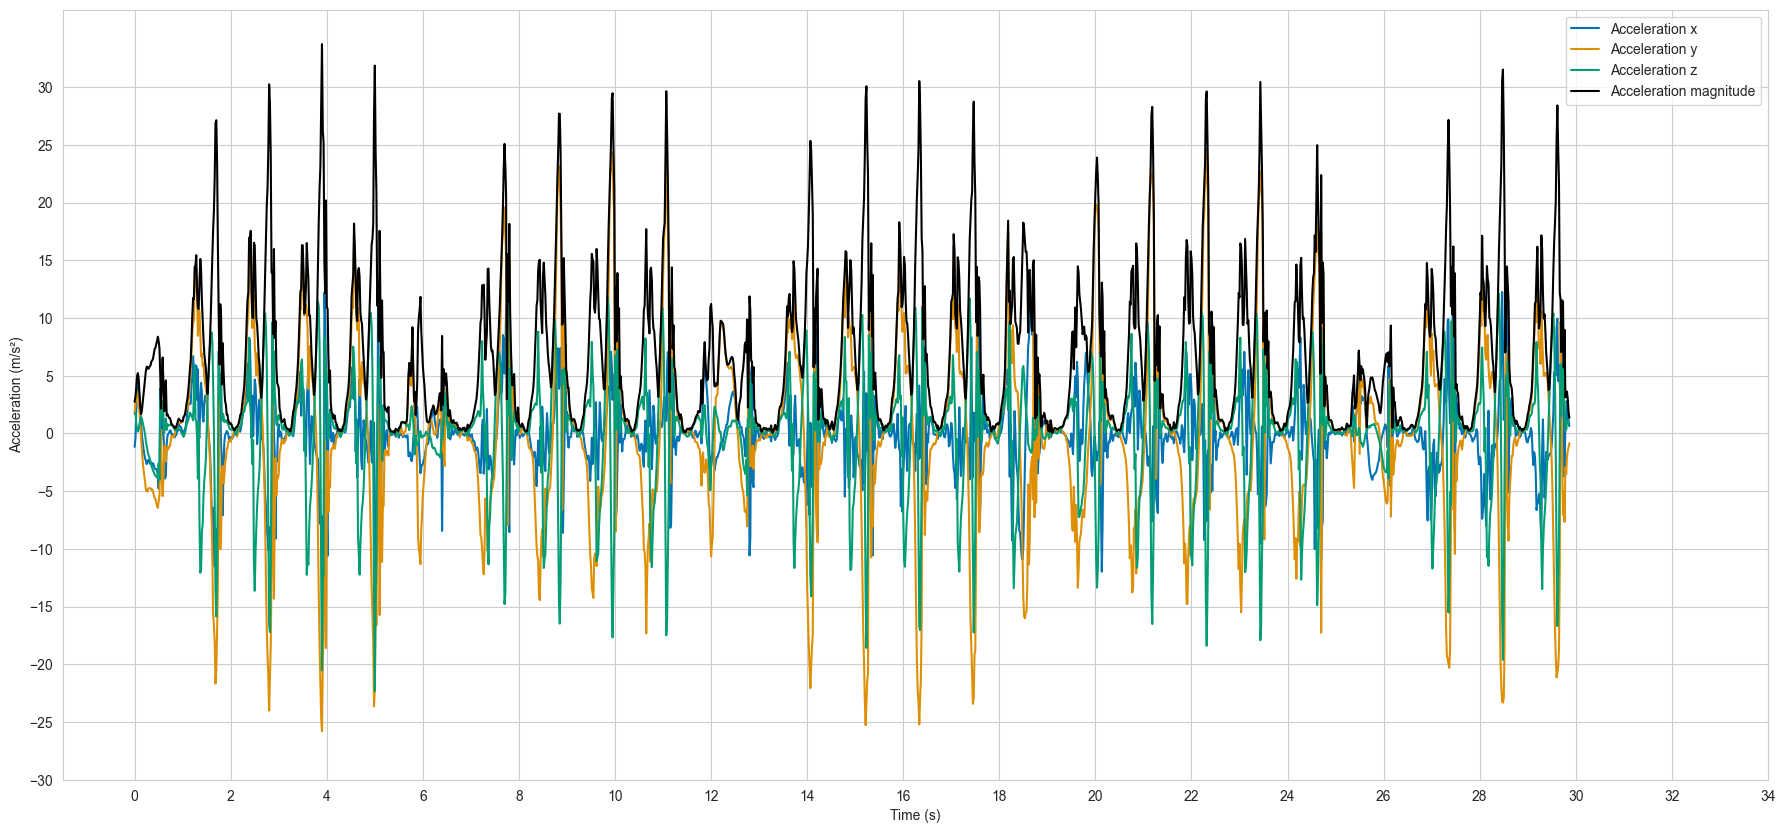

In [22]:
# Plot the acceleration along x, y and z axis for dfs_standard[0]
plt.figure(figsize=(22, 10))
plt.plot(dfs_cognitive[0]['time_s'], dfs_cognitive[0]['freeAcceleration_m/s²_x'], label='Acceleration x')
plt.plot(dfs_cognitive[0]['time_s'], dfs_cognitive[0]['freeAcceleration_m/s²_y'], label='Acceleration y')
# plt.plot(dfs_standard[0]['time_s'], dfs_standard[0]['freeAcceleration_m/s²_y_filtered'], label='y_filtered')
plt.plot(dfs_cognitive[0]['time_s'], dfs_cognitive[0]['freeAcceleration_m/s²_z'], label='Acceleration z')
plt.plot(dfs_cognitive[0]['time_s'], dfs_cognitive[0]['acceleration_magnitude'], label='Acceleration magnitude', color='black')
plt.yticks(np.arange(-30, 35, 5))
plt.xticks(np.arange(0, 35.5, 2))
plt.xlabel('Time (s)')  
plt.ylabel('Acceleration (m/s²)')
plt.legend()
# plt.title('Acceleration along x, y and z axis')
plt.show()

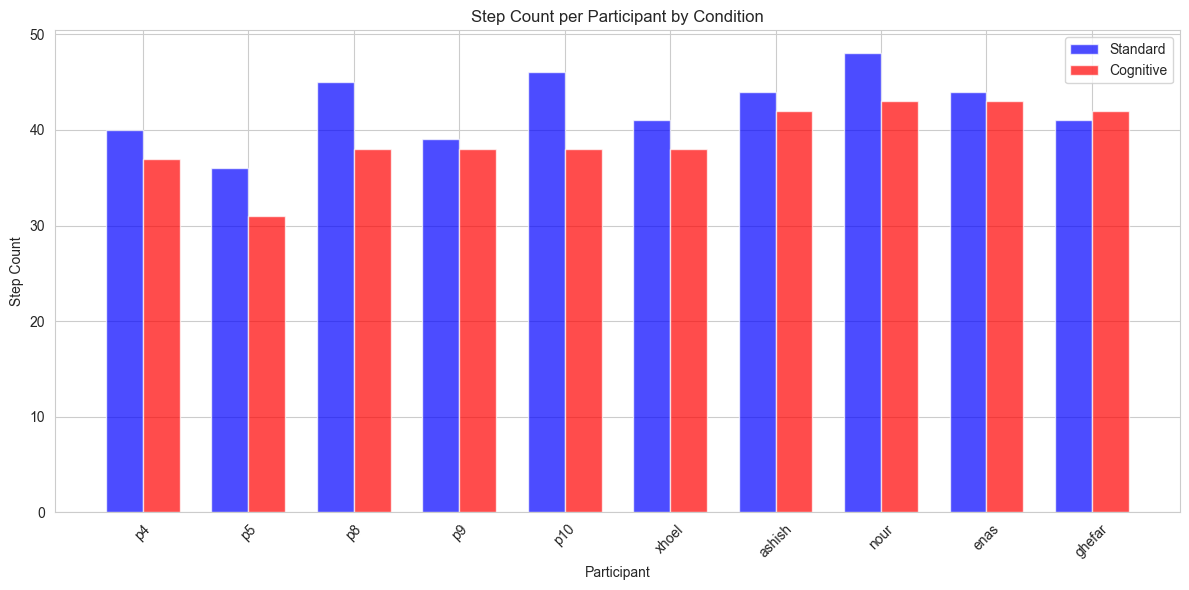

In [23]:
import numpy as np
import matplotlib.pyplot as plt

df = model_df
sns.set_style('whitegrid')
sns.set_palette('colorblind')
# Filter data
df_std = df[df['cognitive_load'] == 0]
df_cog = df[df['cognitive_load'] == 1]

# Align participants by index
participants = df_std['participant'].values
x = np.arange(len(participants))  # integer positions
width = 0.35  # bar width

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, df_std['step_count'].values, width=width, label='Standard', color='blue', alpha=0.7)
plt.bar(x + width/2, df_cog['step_count'].values, width=width, label='Cognitive', color='red', alpha=0.7)

# Labels and formatting
plt.xlabel('Participant')
plt.ylabel('Step Count')
plt.title('Step Count per Participant by Condition')
plt.xticks(x, participants, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
cv_standard = model_df[model_df['cognitive_load'] == 0]['step_count'].values
cv_cognitive = model_df[model_df['cognitive_load'] == 1]['step_count'].values

In [25]:
# Combine data in a single dataframe
df = pd.DataFrame({
    'steps_standard': cv_standard,
    'steps_cognitive': cv_cognitive
}, index=[f'participant {i+1}' for i in range(len(cv_standard))])
df


,steps_standard,steps_cognitive
participant 1,40,37
participant 2,36,31
participant 3,45,38
participant 4,39,38
participant 5,46,38
participant 6,41,38
participant 7,44,42
participant 8,48,43
participant 9,44,43
participant 10,41,42


# Test for normality

In [26]:
# Apply shapiro-wilk test for step_interval_cv for both standard and cognitive
from scipy.stats import shapiro

shapiro_standard = shapiro(model_df[model_df['cognitive_load'] == 0]['step_count'].values)
shapiro_cognitive = shapiro(model_df[model_df['cognitive_load'] == 1]['step_count'].values)

print(shapiro_standard)
print(shapiro_cognitive)

# interpret the shapiro-wilk test results
if shapiro_standard.pvalue > 0.05:
    print("The data is normally distributed for standard")
else:
    print("The data is not normally distributed for standard")

if shapiro_cognitive.pvalue > 0.05:
    print("The data is normally distributed for cognitive")
else:
    print("The data is not normally distributed for cognitive")

ShapiroResult(statistic=np.float64(0.9756260808786489), pvalue=np.float64(0.9375567051767536))
ShapiroResult(statistic=np.float64(0.8539503045291481), pvalue=np.float64(0.06471774073995057))
The data is normally distributed for standard
The data is normally distributed for cognitive


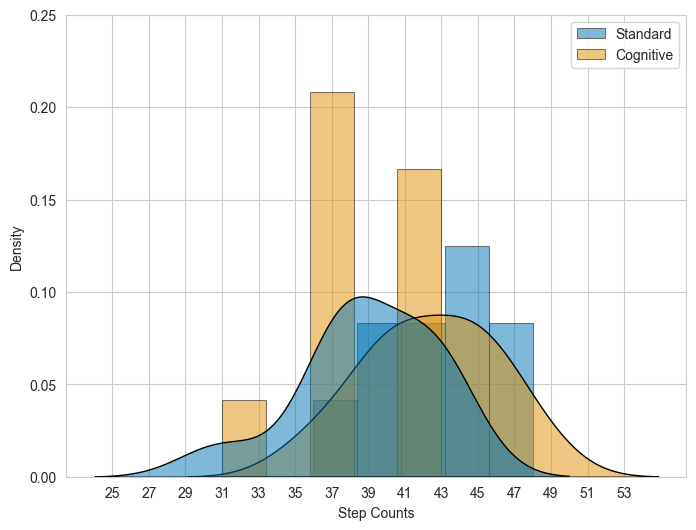

In [27]:
# Plot the cv_standard and cv_cognitive as histogram
plt.figure(figsize=(8, 6))
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.hist(cv_standard, bins=5, label='Standard', edgecolor='black', linewidth=0.75, density=True, fill=True, alpha=0.5)
plt.hist(cv_cognitive, bins=5, label='Cognitive', edgecolor='black', linewidth=0.75, density=True, fill=True, alpha=0.5)
# plot kde for cv_standard
cb_colors = sns.color_palette("colorblind", n_colors=3)
sns.kdeplot(cv_standard, color=cb_colors[1], fill=True, alpha=0.5, edgecolor='black')
sns.kdeplot(cv_cognitive, color=cb_colors[0], fill=True, alpha=0.5, edgecolor='black')

plt.legend()
plt.xticks(np.arange(25, 55, 2))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.xlabel('Step Counts')
plt.ylabel('Density')
plt.show()

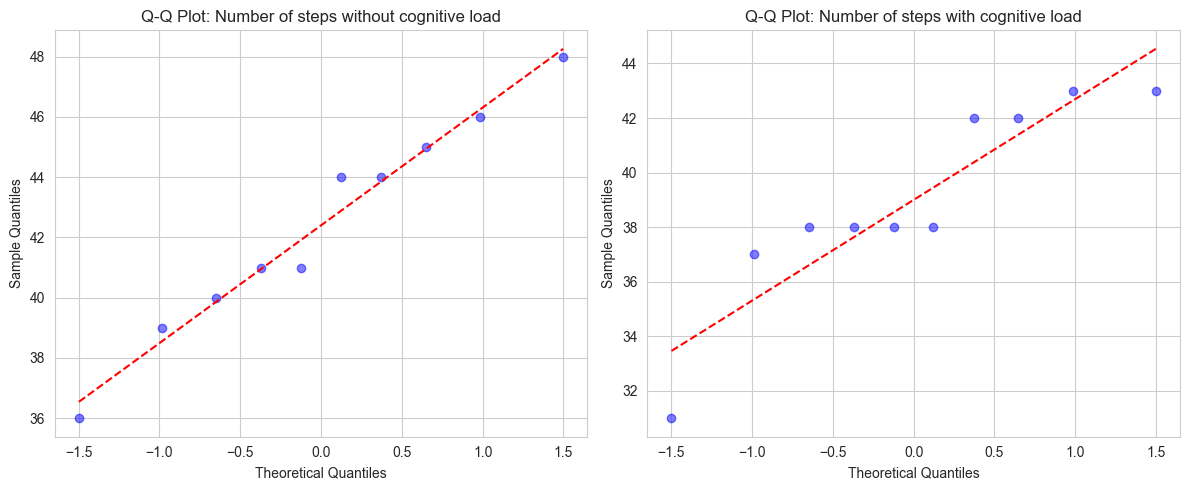

In [28]:
# Create Q-Q plots using seaborn
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set up subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot for standard condition
probplot_data = stats.probplot(cv_standard)
ax1.scatter(probplot_data[0][0], probplot_data[0][1], color='blue', alpha=0.5)
ax1.plot(probplot_data[0][0], probplot_data[1][0] * probplot_data[0][0] + probplot_data[1][1], color='red', linestyle='--')
ax1.set_title("Q-Q Plot: Number of steps without cognitive load")
ax1.set_xlabel("Theoretical Quantiles")
ax1.set_ylabel("Sample Quantiles")

# Q-Q plot for challenge condition
probplot_data = stats.probplot(cv_cognitive)
ax2.scatter(probplot_data[0][0], probplot_data[0][1], color='blue', alpha=0.5)
ax2.plot(probplot_data[0][0], probplot_data[1][0] * probplot_data[0][0] + probplot_data[1][1], color='red', linestyle='--')
ax2.set_title("Q-Q Plot: Number of steps with cognitive load")
ax2.set_xlabel("Theoretical Quantiles")
ax2.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()


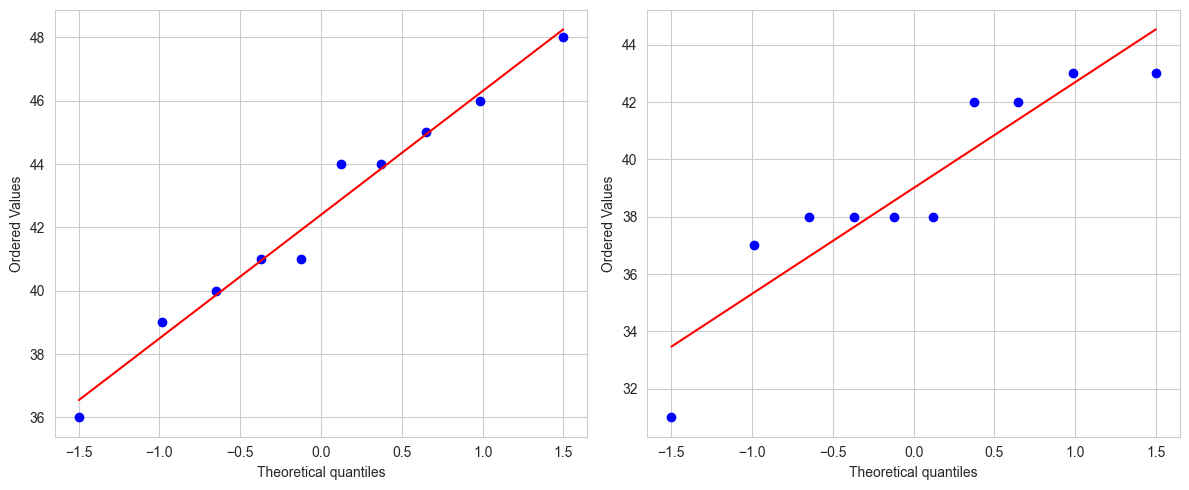

In [29]:
# Create Q-Q plots to assess normality
import scipy.stats as stats
import matplotlib.pyplot as plt

# Set up subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot for standard condition
stats.probplot(cv_standard, dist="norm", plot=ax1)
ax1.set_title("")

# Q-Q plot for challenge condition  
stats.probplot(cv_cognitive, dist="norm", plot=ax2, )
ax2.set_title("")

plt.tight_layout()
plt.show()


Shapiro-Wilk test: p-value = 0.0647
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is normally distributed


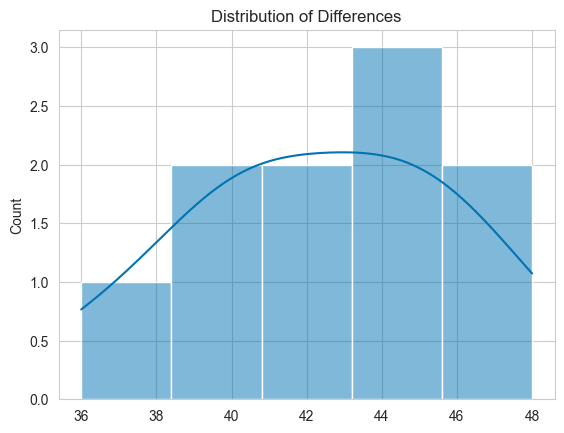

In [30]:
from scipy.stats import shapiro

 
stat, p = shapiro(cv_cognitive)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(cv_standard, kde=True)
plt.title("Distribution of Differences")
plt.show()


# Statistical tests

In [31]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(cv_standard, cv_cognitive)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

if p_val <= 0.05:
    print("Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.")
else:
    print("Fail to reject H_0: no significant difference")

Paired t-test: t = 3.791, p = 0.0043
Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.


In [32]:
from scipy.stats import ttest_rel

# Two-sided t-test
t_stat, p_val_two_sided = ttest_rel(cv_cognitive, cv_standard)

# Mean difference
mean_diff = np.mean(cv_cognitive - cv_standard)

# One-sided p-value (H₁: Challenge < Standard)
if mean_diff < 0:
    p_val_one_sided = p_val_two_sided / 2
else:
    p_val_one_sided = 1 - (p_val_two_sided / 2)

# Results
print(f"t = {t_stat:.3f}, one-sided p = {p_val_one_sided:.4f}")

# Conclusion
if p_val_one_sided < 0.05:
    print("Reject H₀: Significant decrease in count with challenge.")
else:
    print("Fail to reject H₀: No significant decrease observed.")

t = -3.791, one-sided p = 0.0021
Reject H₀: Significant decrease in count with challenge.


# Machine learning

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold

sns.set_style('whitegrid')
sns.set_palette('colorblind')

In [34]:
# Data to be used 
model_df

,participant,cognitive_load,step_interval_cv,step_count,step_rate,step_efficiency,activity_regularity,mean_acceleration_magnitude,mean_velocity_magnitude
0,p4,0,0.388231,40,1.333333,2.575783,103.031337,4.691962,1.283002
1,p4,1,0.545334,37,1.233333,1.833739,67.848334,4.691962,1.283002
2,p5,0,0.430149,36,1.200000,2.324776,83.691952,4.014517,1.075597
3,p5,1,0.548322,31,1.033333,1.823747,56.536147,4.014517,1.075597
4,p8,0,0.327048,45,1.500000,3.057653,137.594401,4.993903,1.023599
5,p8,1,0.476060,38,1.266667,2.100575,79.821855,4.993903,1.023599
6,p9,0,0.452225,39,1.300000,2.211289,86.240264,4.464957,0.988180
7,p9,1,0.430520,38,1.266667,2.322771,88.265300,4.464957,0.988180
8,p10,0,0.346599,46,1.533333,2.885175,132.718061,5.424522,1.079139
9,p10,1,0.598251,38,1.266667,1.671539,63.518470,5.424522,1.079139


In [35]:
df_std[['participant', 'step_count']] 


,participant,step_count
0,p4,40
2,p5,36
4,p8,45
6,p9,39
8,p10,46
10,xhoel,41
12,ashish,44
14,nour,48
16,enas,44
18,ghefar,41


In [36]:
df_cog[['participant', 'step_count']]

,participant,step_count
1,p4,37
3,p5,31
5,p8,38
7,p9,38
9,p10,38
11,xhoel,38
13,ashish,42
15,nour,43
17,enas,43
19,ghefar,42


In [37]:
merged_df = pd.merge(df_std[['participant', 'step_count']] , df_cog[['participant', 'step_count']], on='participant', suffixes=('_standard', '_challenge'))
merged_df


,participant,step_count_standard,step_count_challenge
0,p4,40,37
1,p5,36,31
2,p8,45,38
3,p9,39,38
4,p10,46,38
5,xhoel,41,38
6,ashish,44,42
7,nour,48,43
8,enas,44,43
9,ghefar,41,42


In [38]:
# Export as csv
merged_df.to_csv('merged_df.csv', index=False)

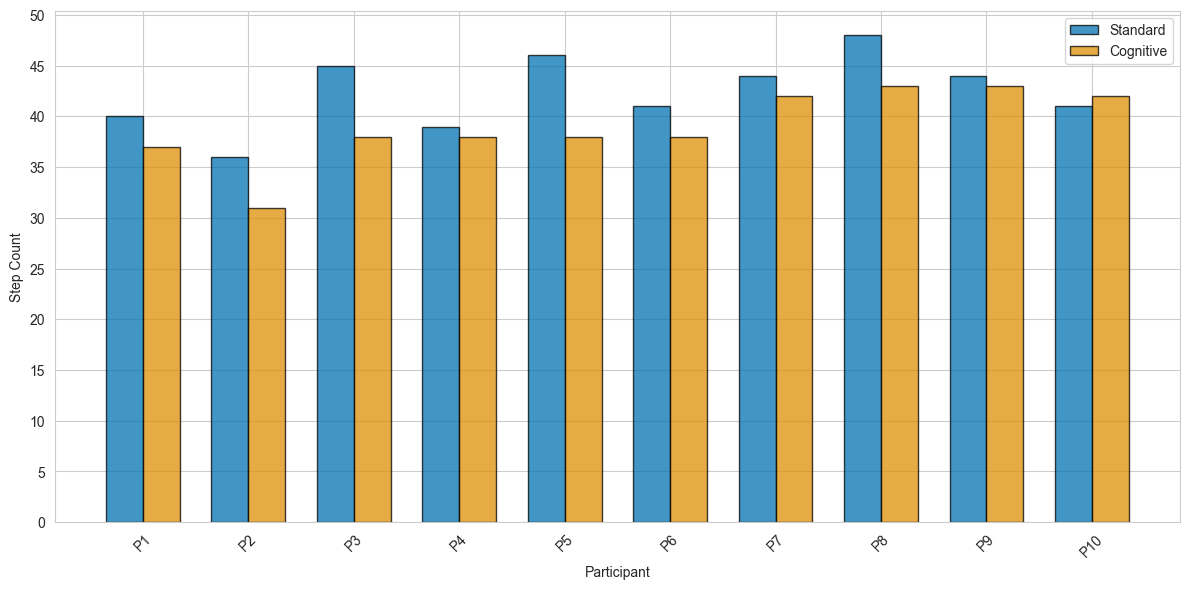

In [39]:
import numpy as np
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
sns.set_palette('colorblind')
# Filter data
df_std = model_df[model_df['cognitive_load'] == 0]
df_cog = model_df[model_df['cognitive_load'] == 1]

# Align participants by index
participants = df_std['participant'].values
x = np.arange(len(participants))  # integer positions
width = 0.35  # bar width

# Plot
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, df_std['step_count'].values, width=width, label='Standard', edgecolor='black', alpha=0.75)
plt.bar(x + width/2, df_cog['step_count'].values, width=width, label='Cognitive', edgecolor='black', alpha=0.75)

# Labels and formatting
plt.xlabel('Participant')
plt.ylabel('Step Count')
# plt.title('Step Count per Participant by Condition')
plt.xticks(x, [f'P{i+1}' for i in x], rotation=45)
plt.yticks(np.arange(0, 54, 5))
plt.legend()
plt.tight_layout()
plt.show()

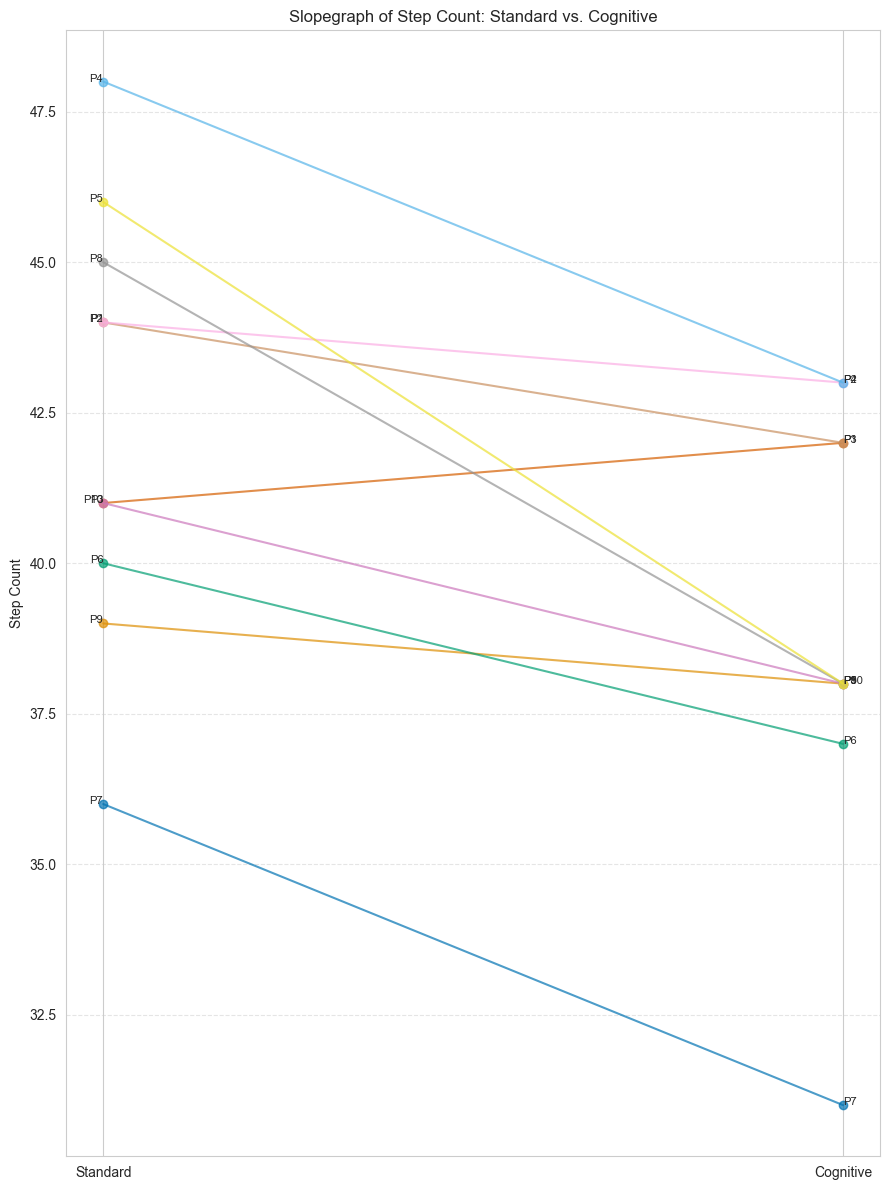

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure consistent style
sns.set_style('whitegrid')
sns.set_palette('colorblind')

# Pivot data to have one row per participant and columns for each condition
df_slope = model_df.pivot(index='participant', columns='cognitive_load', values='step_count')
df_slope.columns = ['Standard', 'Cognitive']  # Rename columns for clarity

# Rename participants as P1, P2, ...
df_slope.index = [f'P{i+1}' for i in range(len(df_slope))]

# Sort by Standard condition (optional, for aesthetics)
df_slope = df_slope.sort_values(by='Standard')

# Plot
fig, ax = plt.subplots(figsize=(9, 12))
for i, row in df_slope.iterrows():
    plt.plot(['Standard', 'Cognitive'], row.values, marker='o', label=i, alpha=0.7)

# Add labels
for i, row in df_slope.iterrows():
    plt.text('Standard', row['Standard'], i, horizontalalignment='right', fontsize=8)
    plt.text('Cognitive', row['Cognitive'], i, horizontalalignment='left', fontsize=8)

plt.title('Slopegraph of Step Count: Standard vs. Cognitive')
plt.ylabel('Step Count')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Final model training pipeline

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = model_df

X = df.drop(columns=['participant', 'cognitive_load'])
y = df['cognitive_load']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Models
| Model                | What It Does                                                                 |
|----------------------|------------------------------------------------------------------------------|
| **Logistic Regression** | Draws a straight line (or boundary) to separate classes. Fast and interpretable. |
| **K-Nearest Neighbors (KNN)** | Looks at the 'k' closest data points and picks the most common class. Simple but can be slow. |
| **Support Vector Machine (SVM)** | Finds the best boundary between classes. Works well for both straight and curved boundaries. |
| **Random Forest**     | Combines many decision trees. Great for accuracy and handling complex data. |
| **Gradient Boosting** | Builds trees step-by-step, focusing on mistakes. Often very accurate.       |
| **Naive Bayes**       | Based on probability and assumes features are independent. Fast and works surprisingly well. |

In [42]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVM (Linear)': SVC(kernel='linear', probability=True),
    'SVM (RBF)': SVC(kernel='rbf', probability=True),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Naive Bayes': GaussianNB()
}

results = []
cv = 5  # 5-fold cross-validation

np.random.seed(42)

for name, model in models.items():
    # Accuracy and F1 scores using cross_val_score (returns array of scores)
    acc_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='f1')
    precision_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='precision')
    recall_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='recall')

    y_probs = cross_val_predict(model, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
    roc_auc = roc_auc_score(y, y_probs)

    results.append({
        'Model': name,
        'Accuracy': np.mean(acc_scores),
        'F1 Score': np.mean(f1_scores),
        'ROC AUC': roc_auc,
        'Precision': np.mean(precision_scores),
        'Recall': np.mean(recall_scores),
    })

/Users/ashish/Desktop/DS4W/ds4w-impact-of-cognitive-load-on-physical-performance/env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ashish/Desktop/DS4W/ds4w-impact-of-cognitive-load-on-physical-performance/env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ashish/Desktop/DS4W/ds4w-impact-of-cognitive-load-on-physical-performance/env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 d

In [43]:
import pandas as pd
results_df = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)
results_df

,Model,Accuracy,F1 Score,ROC AUC,Precision,Recall
2,SVM (Linear),0.70,0.760000,0.350,0.733333,0.9
0,Logistic Regression,0.70,0.726667,0.680,0.733333,0.8
5,Gradient Boosting,0.80,0.693333,0.815,0.733333,0.7
4,Random Forest,0.75,0.653333,0.820,0.866667,0.6
6,Naive Bayes,0.65,0.586667,0.660,0.566667,0.7
3,SVM (RBF),0.70,0.493333,0.430,0.533333,0.5
1,KNN,0.65,0.453333,0.610,0.466667,0.5


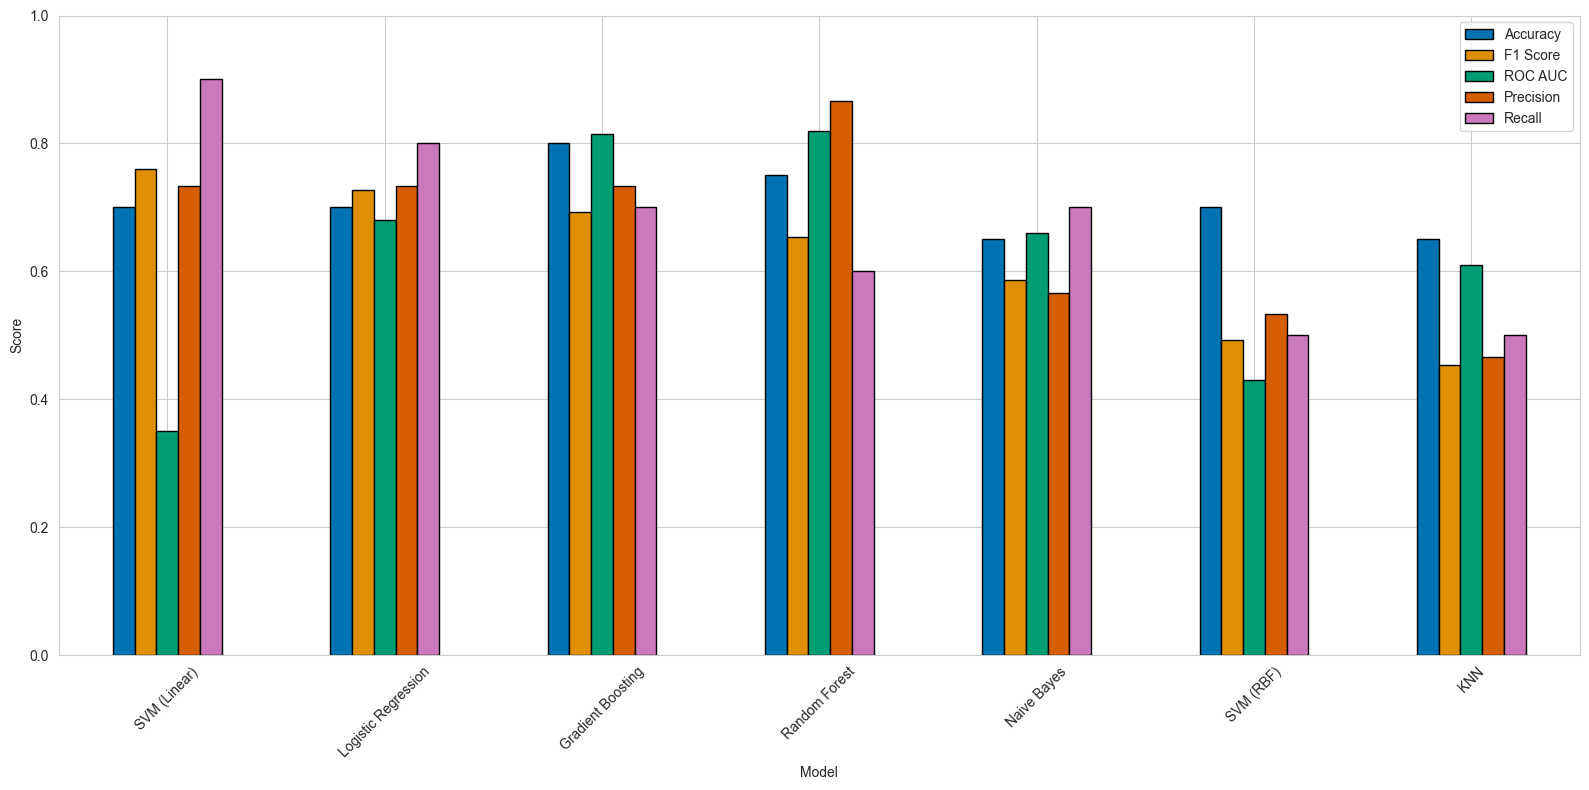

In [44]:
cb_colors = sns.color_palette("colorblind", n_colors=5)

results_df.set_index('Model')[['Accuracy', 'F1 Score', 'ROC AUC', 'Precision', 'Recall']].plot(kind='bar', figsize=(16, 8), color=cb_colors, linewidth=1, edgecolor='black')
# plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Confusion matrix for: Logistic Regression


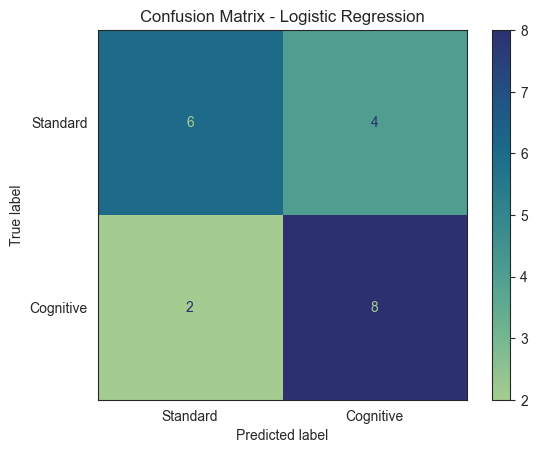

Confusion matrix for: KNN


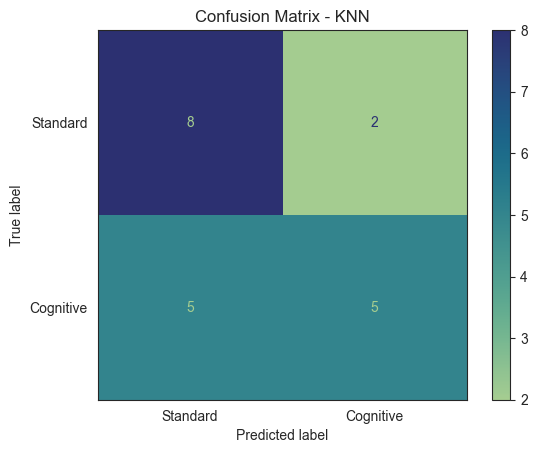

Confusion matrix for: SVM (Linear)


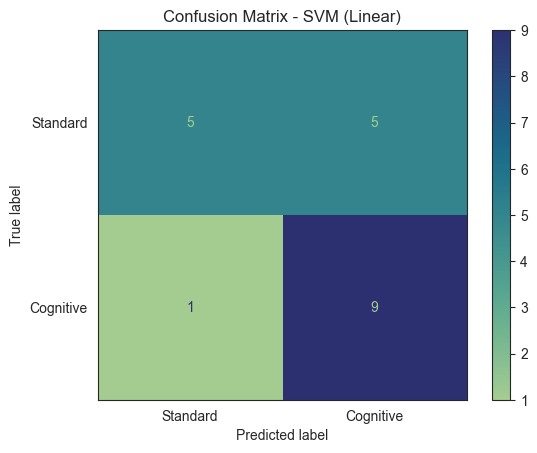

Confusion matrix for: SVM (RBF)


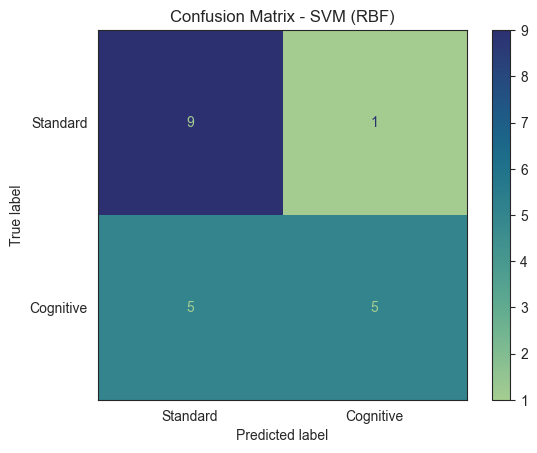

Confusion matrix for: Random Forest


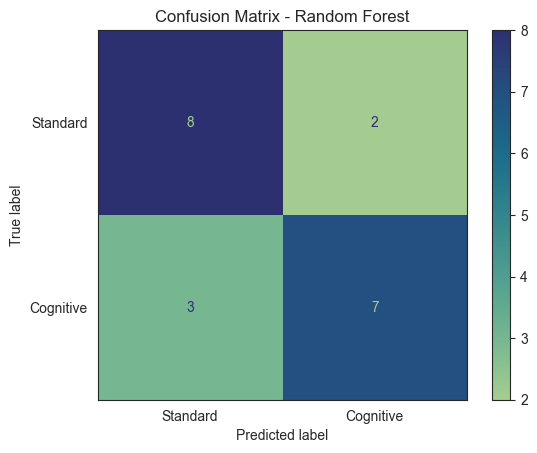

Confusion matrix for: Gradient Boosting


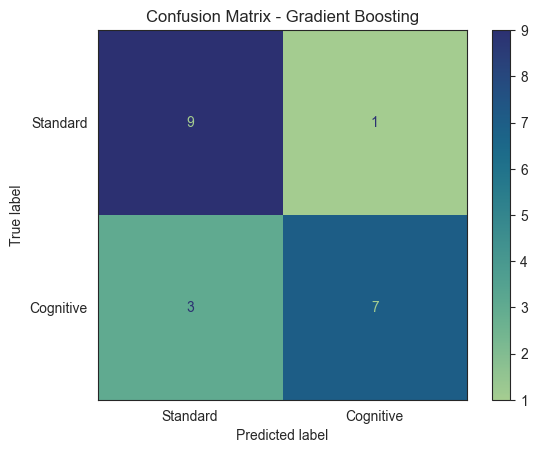

Confusion matrix for: Naive Bayes


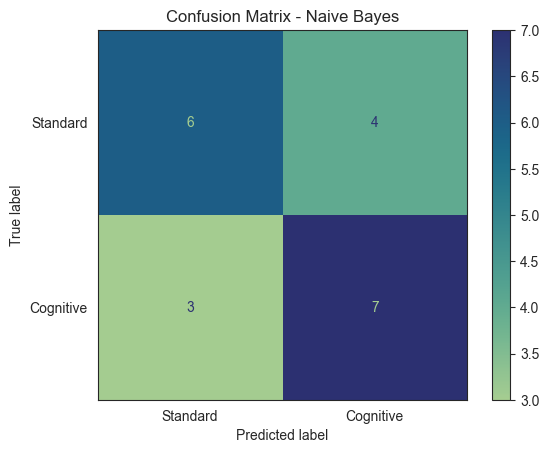

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
sns.set_style('white')

for name, model in models.items():
    print(f"Confusion matrix for: {name}")
    
    # Get cross-validated predictions (labels)
    y_pred_cv = cross_val_predict(model, X_scaled, y, cv=cv)
    
    # Compute confusion matrix
    cm = confusion_matrix(y, y_pred_cv)
    
    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Standard', 'Cognitive'])
    disp.plot(cmap='crest', values_format='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# Hyperparam tuned models

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
seed = 1
np.random.seed(seed)  

# Models and hyperparameters
model_configs = {
    'Logistic Regression': {
        'enabled': True,
        'description': 'Linear model for binary classification',
        'model': Pipeline([
            # ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1000, random_state=1))
        ]),
        'params': {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__penalty': ['l2'],
            'clf__solver': ['lbfgs']
        }
    },
    'KNN': {
        'enabled': True,
        'description': 'Instance-based learner using nearest neighbors',
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        'params': {
            'clf__n_neighbors': [3, 5, 7, 9],
            'clf__weights': ['uniform', 'distance']
        }
    },
    'SVM (Linear)': {
        'enabled': True,
        'description': 'Linear Support Vector Classifier',
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='linear', probability=True, random_state=seed))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10]
        }
    },
    'SVM (RBF)': {
        'enabled': True,
        'description': 'Non-linear SVM with RBF kernel',
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', probability=True, random_state=seed))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__gamma': ['scale', 'auto']
        }
    },
    'Random Forest': {
        'enabled': True,
        'description': 'Ensemble of decision trees with bagging',
        'model': RandomForestClassifier(random_state=seed),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5]
        }
    },
    'Gradient Boosting': {
        'enabled': True,
        'description': 'Boosted trees for improved accuracy',
        'model': GradientBoostingClassifier(random_state=seed),
        'params': {
            'n_estimators': [50, 100],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [3, 5],
            'subsample': [0.8, 1.0]
        }
    },
    'Naive Bayes': {
        'enabled': True,
        'description': 'Simple probabilistic model assuming independence',
        'model': GaussianNB(),
        'params': {}
    }
}

results = []

for name, config in model_configs.items():
    print(f"Tuning {name}")
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_scaled, y)
    
    best_model = grid.best_estimator_
    y_pred = cross_val_predict(best_model, X_scaled, y, cv=5)
    y_prob = cross_val_predict(best_model, X_scaled, y, cv=5, method='predict_proba')[:, 1] if hasattr(best_model, 'predict_proba') else None
    precision_scores = cross_val_predict(best_model, X_scaled, y, cv=5, method='predict_proba')[:, 1] if hasattr(best_model, 'predict_proba') else None
    recall_scores = cross_val_predict(best_model, X_scaled, y, cv=5, method='predict_proba')[:, 1] if hasattr(best_model, 'predict_proba') else None

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'Accuracy': accuracy_score(y, y_pred),
        'F1 Score': f1_score(y, y_pred),
        'ROC AUC': roc_auc_score(y, y_prob) if y_prob is not None else None,
        'Precision': np.mean(precision_scores),
        'Recall': np.mean(recall_scores),
    })
    

Tuning Logistic Regression
Tuning KNN
Tuning SVM (Linear)
Tuning SVM (RBF)
Tuning Random Forest
Tuning Gradient Boosting
Tuning Naive Bayes


# Results


In [48]:
import pandas as pd
results_df_ht = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False)

results_df_ht

,Model,Best Params,Accuracy,F1 Score,ROC AUC,Precision,Recall
5,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.85,0.842105,0.860,0.440018,0.440018
2,SVM (Linear),{'clf__C': 1},0.70,0.750000,0.280,0.503725,0.503725
4,Random Forest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.75,0.736842,0.825,0.485000,0.485000
0,Logistic Regression,"{'clf__C': 10, 'clf__penalty': 'l2', 'clf__sol...",0.70,0.727273,0.740,0.563962,0.563962
3,SVM (RBF),"{'clf__C': 10, 'clf__gamma': 'scale'}",0.75,0.705882,0.560,0.444715,0.444715
1,KNN,"{'clf__n_neighbors': 3, 'clf__weights': 'unifo...",0.65,0.666667,0.725,0.550000,0.550000
6,Naive Bayes,{},0.65,0.666667,0.660,0.482698,0.482698


In [49]:
results_df_ht = results_df_ht.round(2)
results_df_ht.drop(columns=['Best Params'], inplace=True)
results_df_ht.to_csv('results_df_ht.csv', index=False)

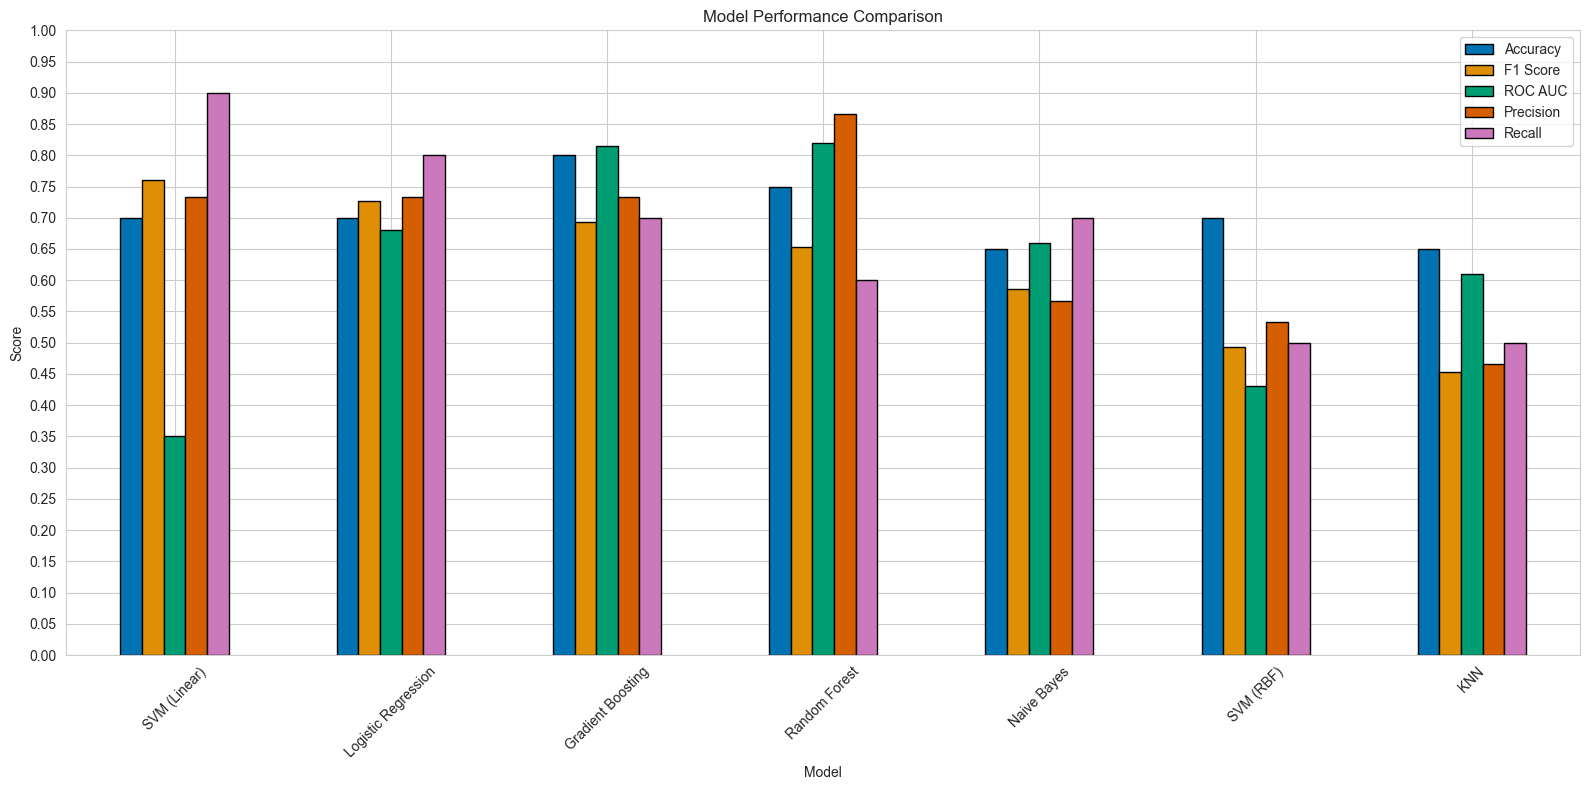

In [50]:
sns.set_style('whitegrid')
sns.set_palette('colorblind')

results_df.set_index('Model')[['Accuracy', 'F1 Score', 'ROC AUC', 'Precision', 'Recall']].plot(kind='bar', figsize=(16, 8), color=cb_colors, linewidth=1, edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.yticks(np.arange(0, 1.1, 0.05))
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Confusion matrix for: Logistic Regression


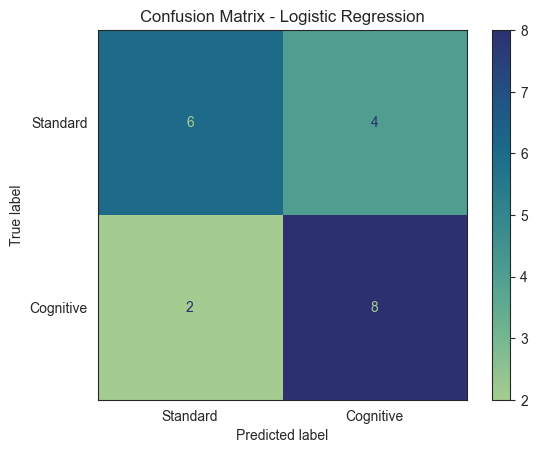

Confusion matrix for: KNN


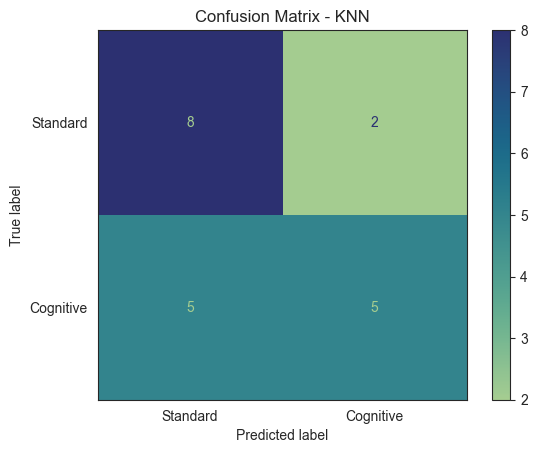

Confusion matrix for: SVM (Linear)


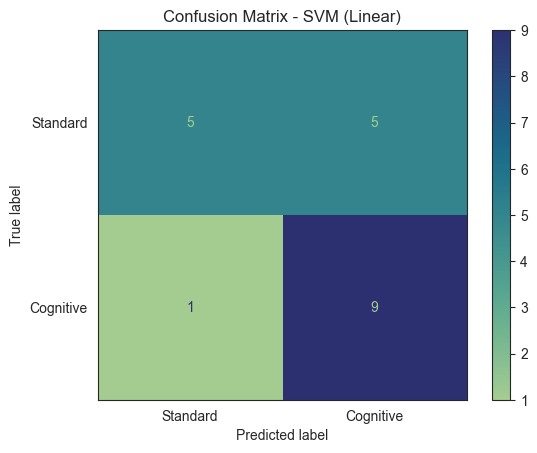

Confusion matrix for: SVM (RBF)


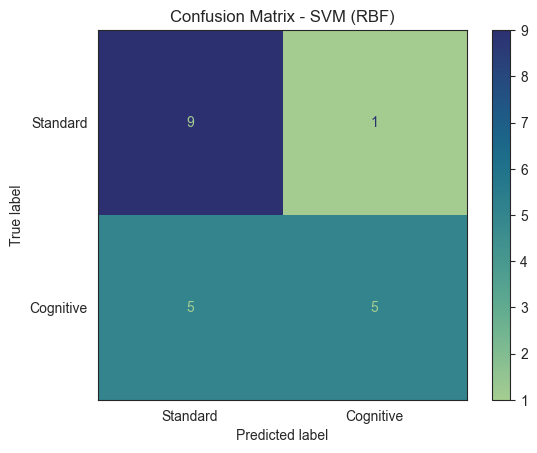

Confusion matrix for: Random Forest


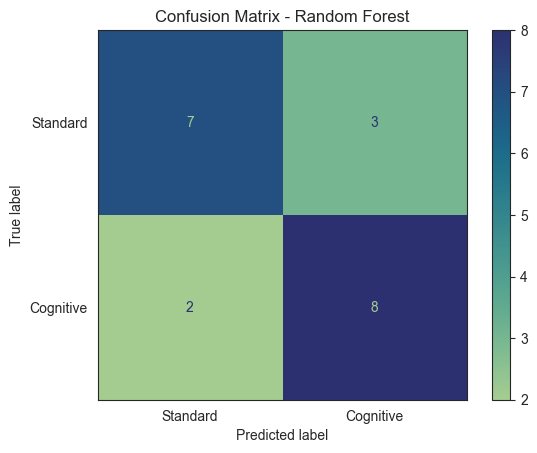

Confusion matrix for: Gradient Boosting


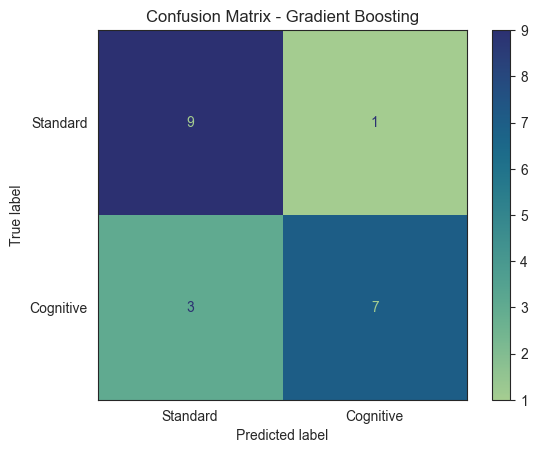

Confusion matrix for: Naive Bayes


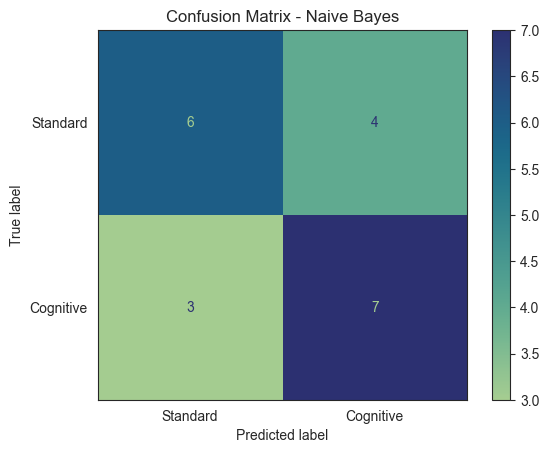

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
sns.set_style('white')

for name, model in models.items():
    print(f"Confusion matrix for: {name}")
    
    # Get cross-validated predictions (labels)
    y_pred_cv = cross_val_predict(model, X_scaled, y, cv=cv)
    
    # Compute confusion matrix
    cm = confusion_matrix(y, y_pred_cv)
    
    # Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Standard', 'Cognitive'])
    disp.plot(cmap='crest', values_format='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# Compare perfornance boost

In [52]:
# Round each column to 2 decimal places
tuned = tuned.round(2)
tuned.to_csv('tuned.csv', index=False)

NameError: name 'tuned' is not defined

In [ ]:

tuned.to_csv('tuned.csv', index=False)

In [ ]:
# Rename columns for clarity
base = results_df.rename(columns={
    'Accuracy': 'Accuracy_Base',
    'F1 Score': 'F1_Base',
    'ROC AUC': 'ROC_AUC_Base',
    'Precision': 'Precision_Base',
    'Recall': 'Recall_Base'
})

tuned= results_df_ht.rename(columns={
    'Accuracy': 'Accuracy_Tuned',
    'F1 Score': 'F1_Tuned',
    'ROC AUC': 'ROC_AUC_Tuned',
    'Precision': 'Precision_Tuned',
    'Recall': 'Recall_Tuned'
})

# Merge on model name
comparison_df = pd.merge(base, tuned, on='Model')

In [ ]:
comparison_df

,Model,Accuracy_Base,F1_Base,ROC_AUC_Base,Precision_Base,Recall_Base,Accuracy_Tuned,F1_Tuned,ROC_AUC_Tuned,Precision_Tuned,Recall_Tuned
0,SVM (Linear),0.70,0.760000,0.350,0.733333,0.9,0.70,0.75,0.28,0.50,0.50
1,Logistic Regression,0.70,0.726667,0.680,0.733333,0.8,0.70,0.73,0.74,0.56,0.56
2,Gradient Boosting,0.80,0.693333,0.815,0.733333,0.7,0.85,0.84,0.86,0.44,0.44
3,Random Forest,0.75,0.653333,0.820,0.866667,0.6,0.75,0.74,0.82,0.48,0.48
4,Naive Bayes,0.65,0.586667,0.660,0.566667,0.7,0.65,0.67,0.66,0.48,0.48
5,SVM (RBF),0.70,0.493333,0.430,0.533333,0.5,0.75,0.71,0.56,0.44,0.44
6,KNN,0.65,0.453333,0.610,0.466667,0.5,0.65,0.67,0.72,0.55,0.55


In [ ]:
comparison_df['accuracy_diff'] = comparison_df['Accuracy_Tuned'] - comparison_df['Accuracy_Base']
comparison_df['f1_diff'] = comparison_df['F1_Tuned'] - comparison_df['F1_Base']
comparison_df['roc_auc_diff'] = comparison_df['ROC_AUC_Tuned'] - comparison_df['ROC_AUC_Base']
comparison_df['precision_diff'] = comparison_df['Precision_Tuned'] - comparison_df['Precision_Base']
comparison_df['recall_diff'] = comparison_df['Recall_Tuned'] - comparison_df['Recall_Base']

comparison_df

,Model,Accuracy_Base,F1_Base,ROC_AUC_Base,Precision_Base,Recall_Base,Accuracy_Tuned,F1_Tuned,ROC_AUC_Tuned,Precision_Tuned,Recall_Tuned,accuracy_diff,f1_diff,roc_auc_diff,precision_diff,recall_diff
0,SVM (Linear),0.70,0.760000,0.350,0.733333,0.9,0.70,0.75,0.28,0.50,0.50,0.00,-0.010000,-7.000000e-02,-0.233333,-0.40
1,Logistic Regression,0.70,0.726667,0.680,0.733333,0.8,0.70,0.73,0.74,0.56,0.56,0.00,0.003333,6.000000e-02,-0.173333,-0.24
2,Gradient Boosting,0.80,0.693333,0.815,0.733333,0.7,0.85,0.84,0.86,0.44,0.44,0.05,0.146667,4.500000e-02,-0.293333,-0.26
3,Random Forest,0.75,0.653333,0.820,0.866667,0.6,0.75,0.74,0.82,0.48,0.48,0.00,0.086667,-1.110223e-16,-0.386667,-0.12
4,Naive Bayes,0.65,0.586667,0.660,0.566667,0.7,0.65,0.67,0.66,0.48,0.48,0.00,0.083333,1.110223e-16,-0.086667,-0.22
5,SVM (RBF),0.70,0.493333,0.430,0.533333,0.5,0.75,0.71,0.56,0.44,0.44,0.05,0.216667,1.300000e-01,-0.093333,-0.06
6,KNN,0.65,0.453333,0.610,0.466667,0.5,0.65,0.67,0.72,0.55,0.55,0.00,0.216667,1.100000e-01,0.083333,0.05


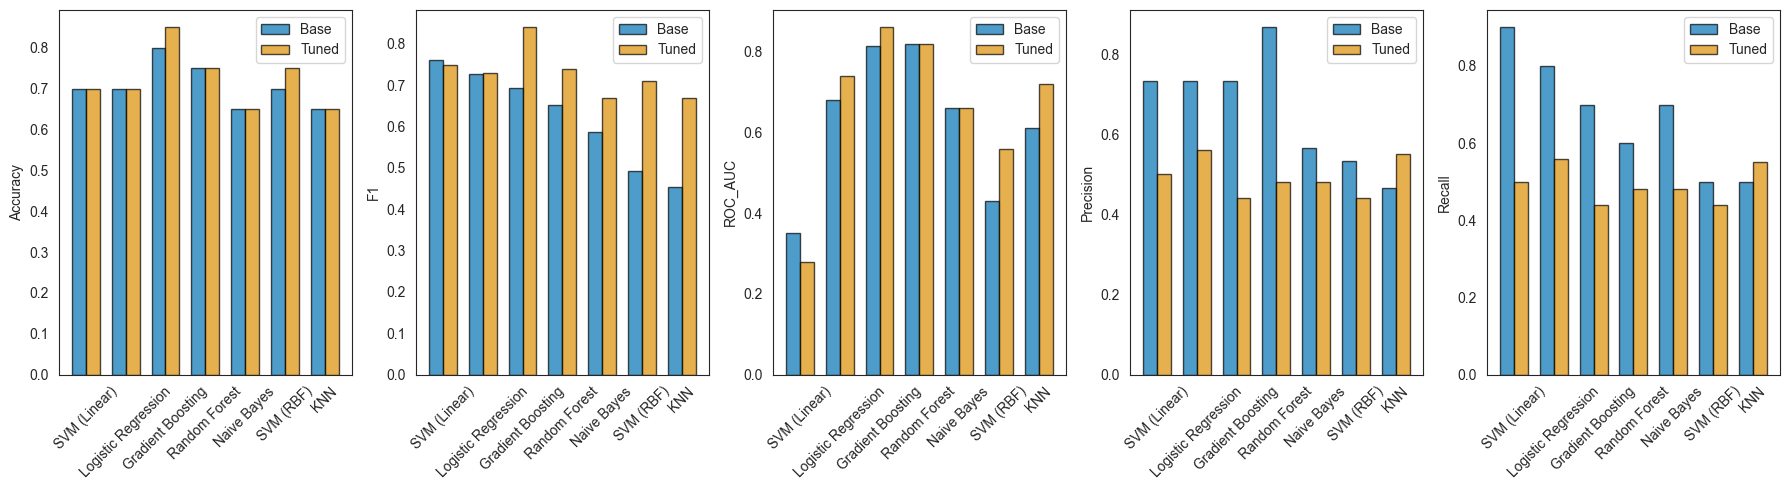

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'F1', 'ROC_AUC', 'Precision', 'Recall']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
bar_width = 0.35
x = np.arange(len(comparison_df['Model']))

for i, metric in enumerate(metrics):
    axes[i].bar(x - bar_width/2, comparison_df[f'{metric}_Base'], width=bar_width, label='Base', alpha=0.7, color=cb_colors[0], edgecolor='black')
    axes[i].bar(x + bar_width/2, comparison_df[f'{metric}_Tuned'], width=bar_width, label='Tuned', alpha=0.7, color=cb_colors[1], edgecolor='black')
    
    # axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(comparison_df['Model'], rotation=45)

    axes[i].legend()
plt.tight_layout()
plt.show()

In [ ]:
for metric in metrics:
    diff = comparison_df[f'{metric}_Tuned'] - comparison_df[f'{metric}_Base']
    improved_models = comparison_df['Model'][diff > 0].tolist()
    print(f"{metric}: {len(improved_models)} model(s) improved → {improved_models}")

Accuracy: 2 model(s) improved → ['Gradient Boosting', 'SVM (RBF)']
F1: 6 model(s) improved → ['Logistic Regression', 'Gradient Boosting', 'Random Forest', 'Naive Bayes', 'SVM (RBF)', 'KNN']
ROC_AUC: 5 model(s) improved → ['Logistic Regression', 'Gradient Boosting', 'Naive Bayes', 'SVM (RBF)', 'KNN']
Precision: 1 model(s) improved → ['KNN']
Recall: 1 model(s) improved → ['KNN']
